---
Auteurs:
  - Franck Deba Wandji
  - Durel Valdes Nziali Tchamou
  

---

# Méthodes des différences finies pour les put Américaines (Euler explicit/ implicite scheme)
---
---


L’objectif est de déterminer une apporximation numérique de la fonction de prix d'un Put américain définie par : $\ v = v(t, s) \ $, $\ t \in [0, T] \ $, $\ s \in \Omega = [S_{\text{min}}, S_{\text{max}}] \ $ et satisfaisant l'EDP suivante :

\begin{cases}
min(\frac{\partial v}{\partial t} - \frac{\sigma^2}{2} s^2 \frac{\partial^2 v}{\partial s^2} - rs \frac{\partial v}{\partial s} + rv, v-\phi) = 0, & t \in (0, T), s \in \Omega, \\
v(t, S_{\text{min}}) = v_\ell(t), & t \in (0, T), \\
v(t, S_{\text{max}}) = v_r(t) \equiv 0, & t \in (0, T), \\
v(0, s) = \phi(s), & s \in \Omega.
\end{cases}

On suppose que : $\ K = 100,  S_{\text{min}} = 50,  S_{\text{max}} = 250,  \sigma = 0.3,  r=0.1 \ $. L'on souhaite évaluer $\ v(T, S_{\text{val}}) \ $ avec  $ S_{\text{val}} = 90.0 $ pour ce faire on aura recours à plusieurs méthodes numériques.

Sur le domaine considéré, on considère le maillage ci-après. On pose $\ h := \frac{S_{\text{max}} - S_{\text{min}}}{I+1} \ $ et $\ \Delta t := \frac{T}{N} \ $, et  

\begin{cases}
s_j := S_{\text{min}} + jh, \quad j = 0, \dots, I+1 \quad \text{(maillage spaciale)} \\
t_n = n\Delta t, \quad n = 0, \dots, N \quad \text{(maillage en temps)}
\end{cases}


Nous nous intéresserons à deux formes de payoff:
- **Payoff=1**: Put Américain de strike K

\begin{equation}
  \phi_1(s) = (K-s)_{+}
\end{equation}
La condition au bord gauche pour se payoff s'écrit $v_l(t) = K - S_{min}$.

- **Payoff=2**: Option digitale Américaine

\begin{equation}
  \phi_2(s) = K \mathcal{1}_{\{\dfrac{K}{2} \leq s \leq K \}}
\end{equation}
La condition au bord gauche pour se payoff s'écrit $v_l(t) = 0 $.

## Schéma d'Euler Explicite (EE)
Comme pour le cas des options européennes, l'on a recours au schéma d'euler explicite qui pour l'EDP du Put américain se décline comme suit : 

\begin{cases}
min(\frac{U^{n+1}_j - U^n_j}{\Delta t} + \frac{\sigma^2}{2} s_j^2 \frac{-U^n_{j-1} + 2U^n_j - U^n_{j+1}}{h^2} - r s_j \frac{U^n_{j+1} - U^n_{j-1}}{2h} + r U^n_j, U^{n+1}_j - \phi(s_j)) = 0  , \quad n = 0, \dots, N-1, \quad j = 1, \dots, I \\ 
U^n_0 = v_\ell(t_n) \\
U^n_{I+1} = v_r(t_n) \\
U^0_j = \phi(s_j) = g_j, \quad j = 1, \dots, I 
\end{cases}

En posant $\alpha_j := \frac{\sigma^2}{2} \frac{s_j^2}{h^2}, et \quad \beta_j := \frac{r s_j}{2h}. \ $ La matrice de discrétisation $\ A \ $ et le vecteur  $\ q(t) \ $ vérifient : $\ (AU + q(t_n))_i : = \alpha_i(-U^n_{i-1} + 2U^n_i - U^n_{i+1}) - \beta_i(U^n_{i+1} - U^n_{i-1}) + r U^n_i = (-\alpha_i + \beta_i)U^n_{i-1} + (2\alpha_i + r)U^n_i + (-\alpha_i - \beta_i)U^n_{i+1}. \ $

Et $\ q(t_n) \ $ contient les valeurs aux bornes $\ U^n_0 = v_\ell(t_n) \ $ et $\ U^n_{I+1} = v_r(t_n) \ $ et est défini comme suit :

\begin{cases}
q(t_n) :=
\begin{pmatrix}
(-\alpha_1 + \beta_1)v_\ell(t_n) \\
0 \\
\vdots \\
0 \\
(-\alpha_I - \beta_I)v_r(t_n)
\end{pmatrix}.
\end{cases}

On réécrit le système d'équation précédent sous forme vectorielle comme suit : 

\begin{cases}
min(\frac{U^{n+1} - U^n}{\Delta t} + A U^n + q(t_n), U^{n+1} -g) = 0, \quad n = 0, \dots, N-1 \\
U^0 = g
\end{cases}

Le système est équivalent à $U^{n+1} = max(U^n - \Delta t (A U^n + q(t_n)), g) $.

## Schéma d'Euler Implicite (EI)

On s'intéresse toujours au schéma d'Euler implicite pour l'option américaine, qui prend la forme suivante :

\begin{equation}
\min\left(\frac{U^{n+1} - U^n}{\Delta t} + A U^{n+1} + q(t_{n+1}), U^{n+1} - g\right) = 0, \quad n = 0, \dots, N-1,
\end{equation}

avec la condition initiale :

\begin{equation}
U^0 = g.
\end{equation}

Étant donné $U^n$, nous cherchons à déterminer $U^{n+1}$. Définissons :

\begin{equation}
B := \text{Id} + \Delta t A, \quad b := U^n - \Delta t \, q(t_{n+1}).
\end{equation}

Le schéma consiste alors à poser $U^{n+1} = x$.
Pour chaque $n$, il faut résoudre le système non linéaire suivant :

\begin{equation}
\min(Bx - b, x - g) = 0, \quad \text{dans } \mathbb{R}^I.
\end{equation}


## Schéma de Crank-Nicolson

\begin{equation}
\min\left(\frac{U^{n+1} - U^n}{\Delta t} + \dfrac{1}{2} (A U^{n+1} + q(t_{n+1})) + \dfrac{1}{2} (A U^{n} + q(t_{n})), U^{n+1} - g\right) = 0, \quad n = 0, \dots, N-1,
\end{equation}
avec la condition initiale :

\begin{equation}
U^0 = g.
\end{equation}

Le problème s'écrit de façon équivalente sous la forme 

\begin{equation}
\min(Bx - b, x - g) = 0, \quad \text{dans } \mathbb{R}^I.
\end{equation}

avec 

\begin{equation}
B := \text{Id} + \dfrac{\Delta t}{2} A, \quad b := (\text{Id} - \dfrac{\Delta t}{2} A)U^n - \dfrac{\Delta t}{2}(q(t_{n}) + q(t_{n+1})).
\end{equation}

## Algorithme PSOR (Projected Successive Over Relaxation)
Le premier algorithme qui est utiliser pour résoudre le problème précédent est l'algorithme PSOR. On suppose que la matrice B du problème d'obstacle peut se décomposer comme suit : $ B = L + U $, où L est une matrice triangulaire inférieure et U une matrice triangulaire supérieure. Le problème d'obstacle est alors équivalent à : 

\begin{equation}
min((L+U)x - b, x - g) = 0
\equiv min(Lx - (b-UX), x - g) = 0
\equiv \begin{pmatrix}
min(B_{11}X_1 - C_1, X_1 - g_1) \\
min(B_{21}X_1 + B_{22}X_2 - C_2, X_2 - g_2) \\
\vdots \\
min(B_{i1}X_1 + ... + B_{ii}X_i - C_i, X_i - g_i)
\end{pmatrix}
\end{equation}

Où $ C := (b-UX). $ Partant de là, on en déduit que : 

\begin{cases}
X_1 = max(\frac{C_1}{B_{11}}, g_1) \\
X_2 = max(\frac{C_2 - B_{21}X_1}{B_{22}}, g_2) \\
\vdots \\
X_i = max(\frac{C_i - \Sigma_{j<i}B_{ij}X_j}{B_{ii}}, g_i) \\
\end{cases}

Cette méthode de descente peut être alors programmé par le pseudo-code ci-après : 

\begin{cases}
\text{for } i = 1 .. n \\
x(i) =( b(i)- \sum_{j=1, j!=i}^J (B(i,j) x(j)) ) / B(i,i) \\
x(i) =max(x(i),g(i)) \\
\end{cases}
Il est alors possible de montrer mathématiquement que lorsque la matrice L a tous ses termes diagonaux strictement positis, l'algortihme PSOR converge. Le code ci-dessous est une implémentation de cet algorithme

## Schéma BDF (Backward Difference Formula)

\begin{equation}
    \min\left(\frac{3 U^{n+1} - 4 U^n + U^{n-1}}{2 \Delta t} + A U^{n+1} + q(t_{n+1}), U^{n+1} - g\right) = 0, \quad n = 1, \dots, N-1,
\end{equation}

avec la condition initiale $U^0 = g$. On détermine $U^1$  à partir du schéma d'Euler implicite.

Le problème s'écrit de façon équivalente sous la forme 

\begin{equation}
\min(Bx - b, x - g) = 0, \quad \text{dans } \mathbb{R}^I.
\end{equation}

avec 

\begin{equation}
B := 3 \text{Id} + 2\Delta t A, \quad b := 4 U^n - U^{n-1} - 2 \Delta t q(t_{n+1}).
\end{equation}

# Programmation des différents schémas présentés

Pour chacune des méthodes présentées ci-dessus, nous proposons ci-dessous une implémentaion dans la classe EulerScheme des schémas:
- "EE-AMER": Schéma Euler Explicite
- "EI-AMER-SPLIT": schéma d'Euler implicite avec splitting
- 'CN-AMER-SPLIT': schéma de Crank-Nicolson  avec slpitting
- 'EI-AMER-PSOR': schéma d'Euler implicite avec la méthode PSOR
- "EI-AMER-NEWTON": schéma d'Euler implicite avec la méthode de Newton
- 'CN-AMER-NEWTON':  schéma de Crank-Nicolson avec la méthode de Newton
- 'BDF-AMER-NEWTON': schéma Backward Difference Formula avec la méthode de Newton

Le schéma choisi est spécifié via le paramètre 'scheme' de la classe ConfigEulerScheme.
Tous les tests numériques sont implémentés dans la classe NumericalTest

In [1]:
# Libraries utiles
import numpy as np
import matplotlib.pyplot as plt

from typing import List
import time 
from scipy.stats import norm
import pandas as pd

In [2]:
"""
Module pour la résolution de l'EDP d'une option Américaine (Put et Digitale).
Implémente les schémas :
- "EE-AMER": Schéma Euler Explicite
- "EI-AMER-SPLIT": schéma d'Euler implicite avec splitting
- 'CN-AMER-SPLIT': schéma de Crank-Nicolson  avec slpitting
- 'EI-AMER-PSOR': schéma d'Euler implicite avec la méthode PSOR
- "EI-AMER-NEWTON": schéma d'Euler implicite avec la méthode de Newton
- 'CN-AMER-NEWTON':  schéma de Crank-Nicolson avec la méthode de Newton
- 'BDF-AMER-NEWTON': schéma Backward Difference Formula avec la méthode de Newton
"""
class ConfigEulerScheme:
    """Configuration des paramètres numériques."""
    
    def __init__(self, N: int, J: int, Smin: float, Smax: float, scheme: str, payoff: int, omega: float = 1, eta: float = 10e-6, kmax: int = 1000):
        self.N = N          # Pas de temps
        self.J = J          # Points spatiaux
        self.Smin = Smin    # Borne inférieure
        self.Smax = Smax    # Borne supérieure
        self.scheme = scheme  # Type de schéma
        self.payoff = payoff  # choix du payoff: 1 pour Put, 2 pour Digitale
        self.eta = eta        # Précision de la convergence du PSOR
        self.kmax = kmax      # Nombre max d'itérations pour le PSOR
        self.omega = omega    # paramètre de relaxation du PSOR 
                              # omega = 1 correspond à l'absence de relaxation


class EulerScheme:
    """Solveur de l'équation de Black-Scholes pour les payoff 1 et 2."""
    
    def __init__(self, K: float, T: float, sigma: float, r: float, config: ConfigEulerScheme):
        # Paramètres financiers
        self.K = K         # Strike
        self.T = T         # Maturité
        self.sigma = sigma # volatilité
        self.r = r         # Taux d'intérêt
        
        # Configuration numérique
        self.config = config
        self.h = (config.Smax - config.Smin) / (config.J + 1)
        self.dt = T / config.N
        
        # Résultats (sauvegarde pour les graphiques)
        self.s = None
        self.U = None
    
    def phi(self, s: np.array) -> np.array:
        """Payoff """
        if self.config.payoff == 1:
            return np.maximum(self.K - s, 0).reshape(-1, 1)
        elif self.config.payoff == 2:
            val = self.K * (0.5 * self.K <= s) * (s <= self.K)
            return val.reshape(-1, 1)                       

    def uleft(self, t: float) -> float:
        """Condition limite à gauche"""
        if self.config.payoff == 1:
            return self.K - self.config.Smin 
        elif self.config.payoff == 2:
            return 0                            

    def uright(self, t: float) -> float:
        """Condition limite à droite"""
        return 0

    def q(self, t: float, alpha: np.array, beta: np.array) -> np.array:
        """Terme source incluant les conditions limites"""
        q_vec = np.zeros((self.config.J, 1))
        q_vec[0, :] = (-alpha[0] + beta[0]) * self.uleft(t)
        q_vec[-1, :] = (-alpha[-1] - beta[-1]) * self.uright(t)
        return q_vec
    
    def psor(self, B: np.array, g: np.array, x0: np.array, b: np.array) -> np.array:
        x = x0.copy()
        k = 0
        while (k < self.config.kmax):
            xold = x.copy()
            for i in range(self.config.J):
                x[i] = (1- self.config.omega) * x[i] + self.config.omega * (b[i] - (B[i, :i] @ x[:i] + B[i, i+1:] @ x[i+1:])) / B[i, i]
                x[i] = max(x[i], g[i])
            k += 1
            err1 = np.linalg.norm(x - xold)
            err2 = np.linalg.norm(np.minimum(B@x - b, x - g))
            print("k=%3i, |x-xold|=%10.6f, |min(Bx-b, x-g)|=%10.6f\n" % (k, err1, err2))

            if err1 <= self.config.eta:
                break    
        if (k==self.config.kmax):
            print(f"WARNING: The PSOR did not converge with kmax = {k}")
        return x

    def newton(self, B: np.array, g: np.array, x0: np.array, b: np.array) -> np.array:
        x = x0.copy()
        for k in range(self.config.kmax):
            lower = B @ x - b
            upper = x - g
            F = np.minimum(lower, upper)

            if np.linalg.norm(F, ord=2) < self.config.eta:
                return x

            indicatrice = (lower <= upper)[:,0]     
            In = np.eye(B.shape[0])
            F_prime = np.where(indicatrice[:, None], B, In) # Jacobien de F
            dx = np.linalg.solve(F_prime, F)
            x = x - dx

            if np.linalg.norm(dx, ord=2) < self.config.eta:
                return x
        return x
            

    def run(self):
        """Exécute le schéma numérique sélectionné."""
        # Points spatiaux et coefficients
        s = self.config.Smin + self.h * np.arange(1, self.config.J + 1)
        alpha = (self.sigma**2 * s**2) / (2 * self.h**2)
        beta = (self.r * s) / (2 * self.h)
        
        # Construction de la matrice A
        A = np.zeros((self.config.J, self.config.J))
        for j in range(self.config.J):
            A[j, j] = 2 * alpha[j] + self.r
            if j < self.config.J - 1:
                A[j, j + 1] = -alpha[j] - beta[j]
            if j > 0:
                A[j, j - 1] = -alpha[j] + beta[j]
        
        # Initialisation
        t = 0
        g = self.phi(s)
        U = g.copy()
        
        # Schéma Euler Explicite
        if self.config.scheme == "EE-AMER":
            for _ in range(self.config.N):
                t += self.dt
                U = np.maximum(U - self.dt * (A @ U + self.q(t, alpha, beta)), g)  # taking maximum for each component

        # Schéma Euler Implicite avec Split
        elif self.config.scheme == "EI-AMER-SPLIT":
            A_IE = np.eye(self.config.J) / self.dt + A
            for _ in range(self.config.N):
                t += self.dt
                b = U / self.dt - self.q(t, alpha, beta)
                U_prime = np.linalg.solve(A_IE, b)
                U = np.maximum(U_prime, g)
        
        # Schéma Crank-Nicolson avec Split
        elif self.config.scheme == 'CN-AMER-SPLIT':
            A_plus = 2 * np.eye(self.config.J) / self.dt + A
            A_moins = 2 * np.eye(self.config.J) / self.dt - A
            for _ in range(self.config.N):
                t += self.dt
                b = A_moins @ U - (self.q(t, alpha, beta) + self.q(t - self.dt, alpha, beta))
                U_prime = np.linalg.solve(A_plus, b)
                U = np.maximum(U_prime, g)
                
        # Schéma Euler Implicite avec PSOR algorithm
        elif self.config.scheme == 'EI-AMER-PSOR':
            B = np.eye(self.config.J) + self.dt * A
            for _ in range(self.config.N):
                t += self.dt
                b = U - self.dt * self.q(t, alpha, beta)
                U = self.psor(B, g, U, b)
        
        # Schéma Euler Implicite avec Newton method
        elif self.config.scheme == 'EI-AMER-NEWTON':
            B = np.eye(self.config.J) + self.dt * A
            for _ in range(self.config.N):
                t += self.dt
                b = U - self.dt * self.q(t, alpha, beta)
                U = self.newton(B, g, U, b)
        
        # Schéma Crank-Nicolson avec Newton method
        elif self.config.scheme == 'CN-AMER-NEWTON':
            B = np.eye(self.config.J) + 0.5 * self.dt * A
            A_moins = np.eye(self.config.J) - 0.5 * self.dt * A
            for _ in range(self.config.N):
                t += self.dt
                b = A_moins @ U - 0.5 * self.dt * (self.q(t, alpha, beta) + self.q(t - self.dt, alpha, beta))
                U = self.newton(B, g, U, b)

        # Schéma BDF avec Newton method
        elif self.config.scheme == 'BDF-AMER-NEWTON':
            # Step 1: using EI scheme to compute U1
            U_prec = g.copy()
            A_IE = np.eye(self.config.J) / self.dt + A
            t += self.dt
            b = U_prec / self.dt - self.q(t, alpha, beta)
            U = np.maximum(np.linalg.solve(A_IE, b), g)  # This is U1

            # Step 2: BDF
            B = 3 * np.eye(self.config.J) + 2 * self.dt * A
            for _ in range(self.config.N - 1):
                t += self.dt
                b = 4 * U - U_prec - 2 * self.dt * self.q(t, alpha, beta)
                U_prec = U.copy()
                U = self.newton(B, g, U, b) # We use the newton algorithm to solve here
        
        self.s = np.zeros(self.config.J + 2)
        self.s[0] = self.config.Smin
        self.s[1:self.config.J + 1] = s
        self.s[-1] = self.config.Smax

        # on rajoute les bords    
        self.U = np.zeros((self.config.J + 2, U.shape[1]))
        self.U[1:self.config.J + 1,:] = U
        self.U[0,:] = self.uleft(self.T)
        self.U[-1,:] = self.uright(self.T)   

    def interpolate(self, sval: float) -> float:
        """Interpolation linéaire de la solution."""
        i = 0
        while i < len(self.s) - 1 and sval > self.s[i + 1]:
            i += 1
        if i >= len(self.s) - 1:
            return self.U[-1, 0]
        return ((self.s[i + 1] - sval) * self.U[i, 0] + (sval - self.s[i]) * self.U[i + 1, 0]) / self.h

    def plot(self):
        """Visualisation de la solution et du payoff."""
        s_plot = np.linspace(self.config.Smin, self.config.Smax, 500)
        payoff = self.phi(s_plot)
        
        plt.figure(figsize=(8, 4))
        plt.plot(s_plot, payoff, 'k--', label=f'Payoff={self.config.payoff}', alpha=0.7)
        plt.plot(self.s, self.U, 'b-', label=f"{self.config.scheme}", linewidth=2)
        
        plt.title(f"Payoff {self.config.payoff}, T={self.T}, N={self.config.N}, J={self.config.J}")
        plt.xlabel("Prix du sous-jacent (S)")
        plt.ylabel("Prix de l'option")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Programming Numerical Tests

In [3]:
"""
Module de tests numériques pour les schémas implémentés dans la classe EulerScheme.
"""

# Classe de configuration pour les tests numériques
class ConfigNumericalTest:
    """
    Stocke les paramètres de configuration pour les tests numériques.
    
    Attributes:
        Smin (float): Borne inférieure du domaine spatial
        Smax (float): Borne supérieure du domaine spatial  
        Sval (float): Point d'évaluation pour calculer l'erreur
        scheme (str): Type de schéma ("EE", "EI" ou "CN")
    """
    def __init__(self, Smin: float, Smax: float, Sval: float, scheme: str, payoff: int, K: float, T: float, sigma: float, r: float):
        self.Smin = Smin    # Minimum du prix du sous-jacent
        self.Smax = Smax    # Maximum du prix du sous-jacent
        self.Sval = Sval    # Prix où on évalue la solution
        self.scheme = scheme  # Schéma numérique à tester
        self.payoff = payoff
        self.K = K            # Strike
        self.T = T            # Maturité
        self.sigma = sigma    # Volatilité 
        self.r = r            # Taux d'intérêt 


# Classe principale pour exécuter les tests numériques
class NumericalTest:
    """
    Classe qui implémente une série de tests numériques pour évaluer
    les performances des schémas de différences finies.
    
    Attributes:
        configTest (ConfigNumericalTest): Configuration des tests
        K (float): Prix d'exercice de l'option (strike)
        T (float): Maturité en années
        sigma (float): Volatilité du sous-jacent
        r (float): Taux d'intérêt sans risque
    """
    
    # Compteur statique pour la numérotation des images
    _plot_counter = 1

    def __init__(self, configTest: ConfigNumericalTest):
        self.configTest = configTest  # Configuration des tests
        
        # Paramètres financiers fixes pour tous les tests
        self.K = configTest.K     
        self.T = configTest.T        
        self.sigma = configTest.sigma  
        self.r = configTest.r

        # Variables pour stocker les résultats des tests
        self.result_stability = None     # Résultats test stabilité
        self.result_amplification = None # Résultats matrice amplification (EE seulement)
        self.result_cfl = None           # Résultats condition CFL (EE seulement)
        self.result_numOrd = None        # Résultats ordre de convergence
    
    # 3.a. Test de stabilité numérique et positivité
    def numericalStabilityTest(self, N: int, J: List[int], N_equal_J: bool):
        """
        Teste la stabilité numérique et la positivité de la solution.
        
        Args:
            N (int): Nombre de pas de temps si N_equal_J=False
            J (List[int]): Liste des nombres de points spatiaux à tester
            N_equal_J (bool): Si True, N = J pour chaque test
                              Si False, N est fixe pour tous les tests
        
        Returns:
            Tuple[pd.DataFrame, List[EulerScheme]]: 
                - DataFrame avec les résultats
                - Liste des objets EulerScheme calculés
        """
        schemeRes = []  # Stocke les solveurs calculés
        results = {'N': [], 'J': [], 'norm of U^n': [], 'number of neg. Uj^n': []}
        
        for j in J:
            # Détermine N selon le mode choisi
            if N_equal_J:
                n = j  # N = J
            else:
                n = N  # N fixe
            
            # Configuration et exécution du schéma
            config = ConfigEulerScheme(n, j, self.configTest.Smin, self.configTest.Smax,
             self.configTest.scheme, self.configTest.payoff)
            schema = EulerScheme(self.K, self.T, self.sigma, self.r, config)
            schema.run()
            
            # Enregistrement des résultats
            results['N'].append(n)
            results['J'].append(j)
            results['norm of U^n'].append(np.linalg.norm(schema.U[:,0], 2))  # Norme L2
            results['number of neg. Uj^n'].append(np.sum(schema.U[:,0] < 0)) # Valeurs négatives
            schemeRes.append(schema)
        
        return pd.DataFrame(results), schemeRes

    # 3.c. Fonctions utilitaires 
    def phi(self, s: np.array) -> np.array:
        """Payoff du put Américaine """
        if self.configTest.payoff == 1:
            return np.maximum(self.K - s, 0).reshape(-1, 1)
        elif self.configTest.payoff == 2:
            val = self.K * (0.5 * self.K <= s) * (s <= self.K)
            return val.reshape(-1, 1)

    # 3.e. Calcul de l'ordre de convergence
    def numericalOrder(self, limit: int, N_equal_J: bool) -> pd.DataFrame:
        """
        Calcule l'ordre de convergence numérique du schéma.
        
        Args:
            limit (int): Nombre de raffinement (k dans 2^k)
            N_equal_J (bool): 
                True: N = J (raffinement uniforme)
                False: N = J^2 (respect condition CFL pour EE)
        
        Returns:
            pd.DataFrame: Tableau avec les résultats de convergence
        """
        results = {
            'J': [], 'N': [], 'U(s)': [],      # Paramètres et solution
            'error': [], 'alpha': [], 'beta': [],          # Erreur et ordre
            'tcpu': []             # Erreur exacte et temps CPU
        }
        h_list = []  # Liste des pas spatiaux
        t_list = []

        for k in range(limit):
            # Choix du raffinement selon le mode
            if N_equal_J:
                N = 10 * 2**k
                J = N  # Raffinement uniforme
            else:
                if self.configTest.scheme == "EE-AMER":
                    J = 10 * 2**k  # J + 1 = 10 * 2**k
                    N = int(2 * J**2 / 10) # N = 2 * J^2 / 10 pour respecter CFL
                    J = J - 1
                elif self.configTest.scheme in ["EI-AMER-SPLIT", "CN-AMER-SPLIT"]:
                    J = 20 * 2**k - 1
                    N = 20 * 2**k
                else:
                    J = 10 * 2**k
                    N = J * 10
            
            # Mesure du temps de calcul
            start = time.perf_counter()
            
            # Configuration et exécution
            config = ConfigEulerScheme(N, J, self.configTest.Smin, self.configTest.Smax,
             self.configTest.scheme, self.configTest.payoff)
            schema_explicit = EulerScheme(self.K, self.T, self.sigma, self.r, config)
            schema_explicit.run()
            
            end = time.perf_counter()
            
            # Récupération des données
            s = schema_explicit.s      # Points spatiaux
            U = schema_explicit.U      # Solution numérique
            h = schema_explicit.h      # Pas spatial
            h_list.append(h)
            t_list.append(schema_explicit.dt)
            
            # Interpolation linéaire au point Sval
            U_init = schema_explicit.phi(s)  # Solution initiale (payoff)
            i = 0
            while self.configTest.Sval > s[i+1]:
                i += 1
            # Interpolation entre s[i] et s[i+1]
            U_s = ((s[i+1] - self.configTest.Sval) * U[i, 0] + 
                   (self.configTest.Sval - s[i]) * U[i+1, 0]) / h
            U_0 = ((s[i+1] - self.configTest.Sval) * U_init[i, 0] + 
                   (self.configTest.Sval - s[i]) * U_init[i+1, 0]) / h

            # Enregistrement des résultats
            results['J'].append(J)
            results['N'].append(N)
            results['U(s)'].append(U_s)
            results['tcpu'].append(end - start)  # Temps CPU
            
            # Calcul de l'ordre de convergence
            if k > 0:
                # Erreur entre solutions successives
                results['error'].append(abs(results['U(s)'][k-1] - results['U(s)'][k]))
                # Ordre alpha = log(erreur_k-1 / erreur_k) / log(h_k-1 / h_k)
                results['alpha'].append(
                    np.log(results['error'][k-1] / results['error'][k]) / 
                    np.log(h_list[k-1] / h_list[k])
                )
                # Ordre alpha = log(erreur_k-1 / erreur_k) / log(h_k-1 / h_k)
                results['beta'].append(
                    np.log(results['error'][k-1] / results['error'][k]) / 
                    np.log(t_list[k-1] / t_list[k])
                )
            else:
                # Premier raffinement : pas d'ordre à calculer
                results['error'].append(abs(U_0 - results['U(s)'][k]))
                results['alpha'].append(0.0)
                results['beta'].append(0.0)
        
        return pd.DataFrame(results)

    # Méthode principale pour exécuter tous les tests
    def runTest(self):
        """
        Exécute la suite complète des tests numériques.
        Stocke les résultats dans les attributs de la classe.
        """

        # Test de stabilité - Deux scénarios
        # Scénario 1: N = 20 J= 50 sauf pour "EI-AMER-PSOR"
        if self.configTest.scheme == "EI-AMER-PSOR":
            result_stability1, schemeRes1 = self.numericalStabilityTest(
                N=10, J=[99], N_equal_J=False
            )
        else:
            result_stability1, schemeRes1 = self.numericalStabilityTest(
                N=20, J=[50], N_equal_J=False
            )

        # Scénario 2: N = J = 20 
        result_stability2, schemeRes2 = self.numericalStabilityTest(
            N=20, J=[20], N_equal_J=True
        )
        self.result_stability = [result_stability1, result_stability2]
        
        # Visualisation des résultats
        # Numérotation automatique
        num_img = NumericalTest._plot_counter
        NumericalTest._plot_counter += 1
        schemeRes2.extend(schemeRes1)
        self.plot(schemeRes2 , num_img=num_img)

        # Ordres de convergence
        # Deux modes : raffinement uniforme et respect CFL
        result_numOrd = self.numericalOrder(7, N_equal_J=True)   # N = J
        result_numOrd = [result_numOrd, 
                                 self.numericalOrder(7, N_equal_J=False)]  # N = J^2
        self.result_numOrd = result_numOrd.copy()
        
        # Affichage des résultats
        self._print()

    def _print(self):
        """Affiche les résultats des tests de manière formatée."""
        print("----" * 4, f"{self.configTest.scheme}_scheme", "----" * 4)
        print("====" * 16)
        print("Numerical Order (Scénario 1: N = J): \n", self.result_numOrd[0], "\n")
        print("----" * 16)
        if self.configTest.scheme == "EE-AMER":
            print("Numerical Order (Scénario 2: N = 2*J^2 / 10): \n", self.result_numOrd[1], "\n")
        elif self.configTest.scheme in ["EI-AMER-SPLIT", "CN-AMER-SPLIT"]:
            print("Numerical Order (Scénario 2: N = J + 1): \n", self.result_numOrd[1], "\n")
        else:
            print("Numerical Order (Scénario 2: N = J / 10): \n", self.result_numOrd[1], "\n")
        print("====" * 16)

    def plot(self, schemeRes: List[EulerScheme], num_img: int): 
        """
        Affiche les solutions pour différents raffinements.
        
        Args:
            schemeRes (List[EulerScheme]): Liste des solveurs calculés
            num_img (int): Numéro de la figure 
        """
        # Création de la figure avec 4 sous-graphiques (2x2)
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Graphique {num_img}: Schema {self.configTest.scheme} (Payoff={self.configTest.payoff})', fontsize=12)
        
        # Parcours des 4 solveurs
        for j, euler_scheme in enumerate(schemeRes):            
            # Payoff théorique
            S = np.linspace(self.configTest.Smin, self.configTest.Smax, 500)
            payoff_values = self.phi(S)
            axs[j].plot(S, payoff_values, label=r'Payoff', 
                             color='black', linestyle='--')
            
            # Solution numérique
            axs[j].plot(euler_scheme.s, euler_scheme.U, 
                             label=f"{self.configTest.scheme}_Scheme "
                                   f"(N={euler_scheme.config.N}, J={euler_scheme.config.J})", 
                             color='blue')
            
            # Configuration du sous-graphique
            axs[j].set_title(f'N={euler_scheme.config.N}, J={euler_scheme.config.J}')
            axs[j].grid(alpha=0.5)
            axs[j].legend()
            axs[j].set_xlabel('Valeur du sous-jacent (s)')
            axs[j].set_ylabel('Prix du Put Americaine')
        
        # Ajustement de la mise en page
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Espace pour le titre
        plt.show()

## Résultats numériques

In [ ]:
# Paramètres du schéma
Smin = 50 # left truncated domain
Smax = 250 # right truncated domain
Sval = 90
J = 20
N = 20

# Paramètres de l'option
K = 100 # Strike
T = 1 # Maturité
sigma = 0.3 # Volatilité
r = 0.1 # Taux d'intérêt

payoffs = [1, 2]

### Schemas EE-AMER, EI-AMER-SPLIT et CN-AMER-SPLIT


################################################################################
############################# TESTS AVEC PAYOFF 1 ##############################
################################################################################


                 Schéma: EE-AMER


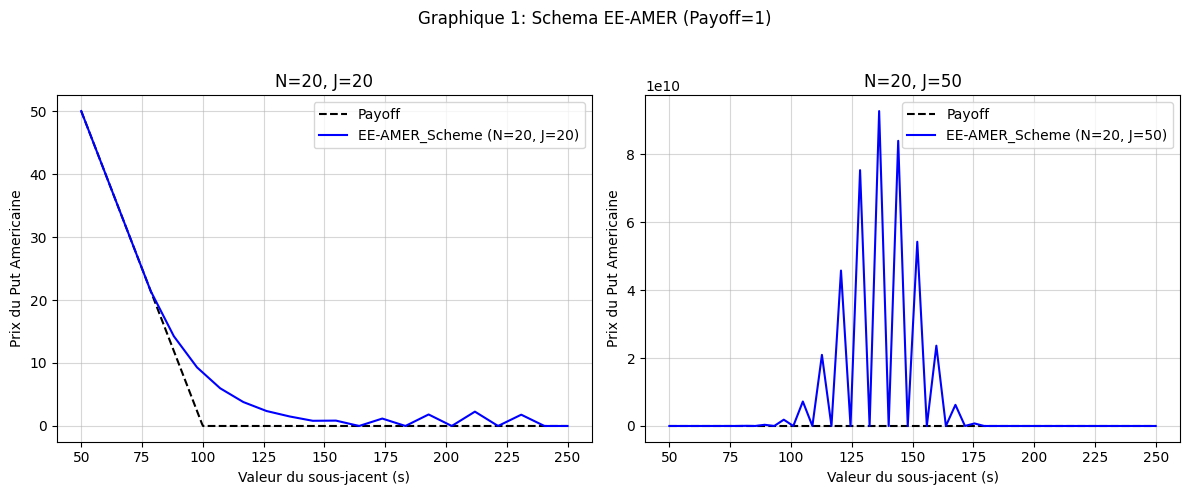

<positron-console-cell-5>:138: RuntimeWarning: overflow encountered in matmul
<positron-console-cell-5>:138: RuntimeWarning: invalid value encountered in matmul


---------------- EE-AMER_scheme ----------------
Numerical Order (Scénario 1: N = J): 
      J    N           U(s)          error       alpha        beta      tcpu
0   10   10   1.296439e+01   2.055296e+00    0.000000    0.000000  0.000177
1   20   20   1.325924e+01   2.948488e-01    3.002831    2.801299  0.000215
2   40   40   7.244158e+02   7.111566e+02  -11.640669  -11.235976  0.000366
3   80   80   3.090619e+29   3.090619e+29  -90.084463  -88.489787  0.000764
4  160  160  7.397716e+107  7.397716e+107 -262.716454 -260.369575  0.002963
5  320  320            NaN            NaN         NaN         NaN  0.028036
6  640  640            NaN            NaN         NaN         NaN  0.130386 

----------------------------------------------------------------
Numerical Order (Scénario 2: N = 2*J^2 / 10): 
      J      N       U(s)     error     alpha      beta      tcpu
0    9     20  12.529703  2.529703  0.000000  0.000000  0.000277
1   19     80  12.947098  0.417396  2.599480  1.299740  0.0

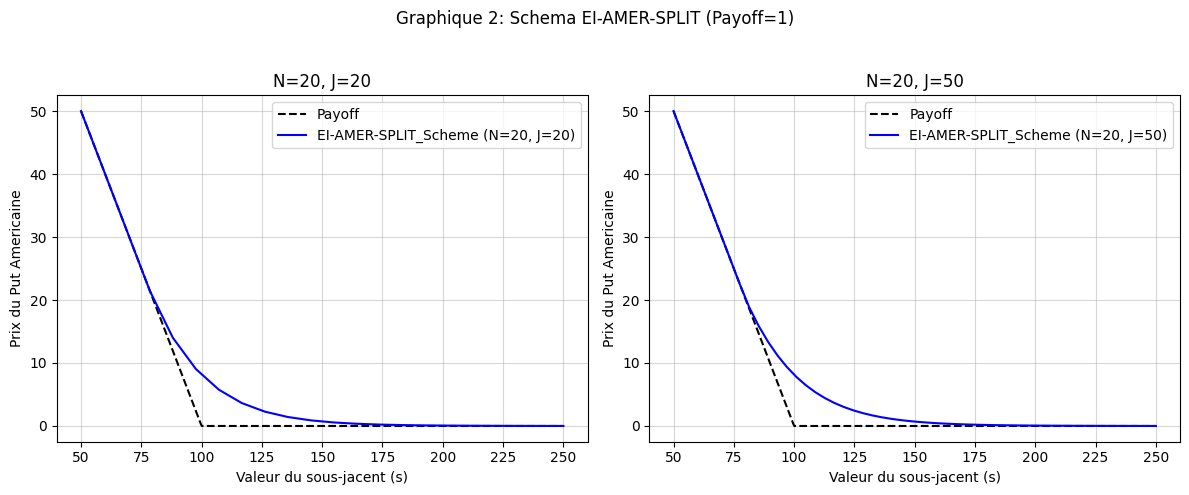

In [ ]:
schemes_to_test = [
    "EE-AMER",
    "EI-AMER-SPLIT",
    "CN-AMER-SPLIT"
]


for payoff in payoffs:
    print(f"\n{'#'*80}")
    print(f"{'#'*29} TESTS AVEC PAYOFF {payoff} {'#'*30}")
    print(f"{'#'*80}\n")
    
    for scheme in schemes_to_test:
        print(f"\n{'='*60}")
        print(f"{' '*15}  Schéma: {scheme}")
        print(f"{'='*60}")
        
        config_test = ConfigNumericalTest(
            Smin=Smin, Smax=Smax, Sval=Sval,
            scheme=scheme,
            payoff=payoff, K=K, T=T, sigma=sigma, r=r
        )
        
        test = NumericalTest(config_test)
        test.runTest()

### PSOR Algorithm

k=  1, |x-xold|=  0.481303, |min(Bx-b, x-g)|= 13.312238

k=  2, |x-xold|=  0.326490, |min(Bx-b, x-g)|= 10.384681

k=  3, |x-xold|=  0.266500, |min(Bx-b, x-g)|=  8.806606

k=  4, |x-xold|=  0.232309, |min(Bx-b, x-g)|=  7.819746

k=  5, |x-xold|=  0.208786, |min(Bx-b, x-g)|=  7.076918

k=  6, |x-xold|=  0.189827, |min(Bx-b, x-g)|=  6.460655

k=  7, |x-xold|=  0.173902, |min(Bx-b, x-g)|=  5.959384

k=  8, |x-xold|=  0.161257, |min(Bx-b, x-g)|=  5.548126

k=  9, |x-xold|=  0.150523, |min(Bx-b, x-g)|=  5.190409

k= 10, |x-xold|=  0.140967, |min(Bx-b, x-g)|=  4.869765

k= 11, |x-xold|=  0.132267, |min(Bx-b, x-g)|=  4.577845

k= 12, |x-xold|=  0.124265, |min(Bx-b, x-g)|=  4.309862

k= 13, |x-xold|=  0.116869, |min(Bx-b, x-g)|=  4.066098

k= 14, |x-xold|=  0.110379, |min(Bx-b, x-g)|=  3.852045

k= 15, |x-xold|=  0.104647, |min(Bx-b, x-g)|=  3.658051

k= 16, |x-xold|=  0.099390, |min(Bx-b, x-g)|=  3.478895

k= 17, |x-xold|=  0.094495, |min(Bx-b, x-g)|=  3.311927

k= 18, |x-xold|=  0.089905, |mi

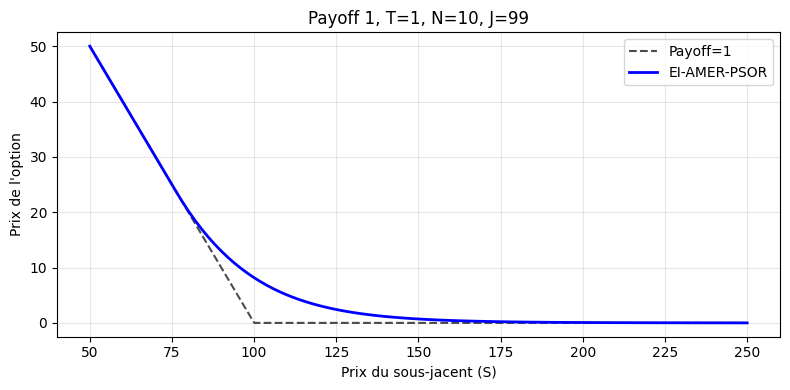

In [ ]:
N = 10
J = 99
sigma = 0.3
config = ConfigEulerScheme(N, J, Smin, Smax, "EI-AMER-PSOR", payoff = 1, omega = 0.5) #prendre omega = 1 pour le cas PSOR non relaxé
schema_implicit = EulerScheme(K, T, sigma, r, config)
schema_implicit.run()
schema_implicit.plot()

k=  1, |x-xold|= 51.526692, |min(Bx-b, x-g)|=312.225770

k=  2, |x-xold|= 17.058722, |min(Bx-b, x-g)|=174.848482

k=  3, |x-xold|=  8.660254, |min(Bx-b, x-g)|=125.218467

k=  4, |x-xold|=  6.082763, |min(Bx-b, x-g)|=102.227840

k=  5, |x-xold|=  3.872983, |min(Bx-b, x-g)|= 92.638673

k=  6, |x-xold|=  3.316625, |min(Bx-b, x-g)|= 82.065529

k=  7, |x-xold|=  2.000000, |min(Bx-b, x-g)|= 73.889586

k=  8, |x-xold|=  2.645751, |min(Bx-b, x-g)|= 67.410935

k=  9, |x-xold|=  2.236068, |min(Bx-b, x-g)|= 67.905611

k= 10, |x-xold|=  2.236068, |min(Bx-b, x-g)|= 59.819809

k= 11, |x-xold|=  0.000000, |min(Bx-b, x-g)|= 59.819809

k=  1, |x-xold|=  5.916080, |min(Bx-b, x-g)|=109.516126

k=  2, |x-xold|=  5.196152, |min(Bx-b, x-g)|= 94.847697

k=  3, |x-xold|=  3.464102, |min(Bx-b, x-g)|= 85.630785

k=  4, |x-xold|=  3.741657, |min(Bx-b, x-g)|= 76.215638

k=  5, |x-xold|=  2.645751, |min(Bx-b, x-g)|= 71.243172

k=  6, |x-xold|=  2.236068, |min(Bx-b, x-g)|= 70.188428

k=  7, |x-xold|=  2.236068, |mi

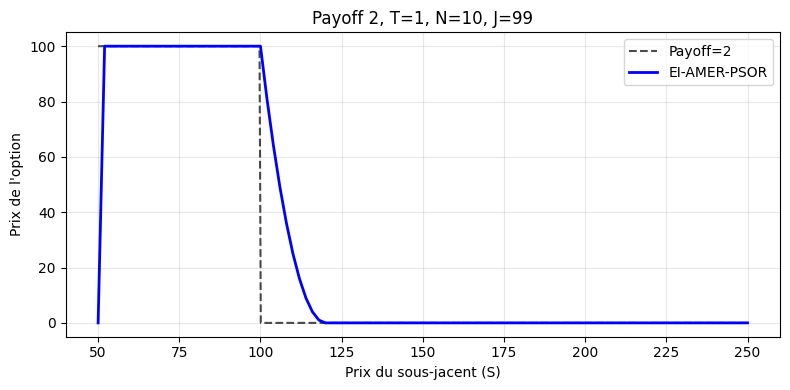

In [ ]:
N = 10
J = 99
sigma = 0.3
config = ConfigEulerScheme(N, J, Smin, Smax, "EI-AMER-PSOR", payoff = 2)
schema_implicit = EulerScheme(K, T, sigma, r, config)
schema_implicit.run()
schema_implicit.plot()

### Higher order schemes

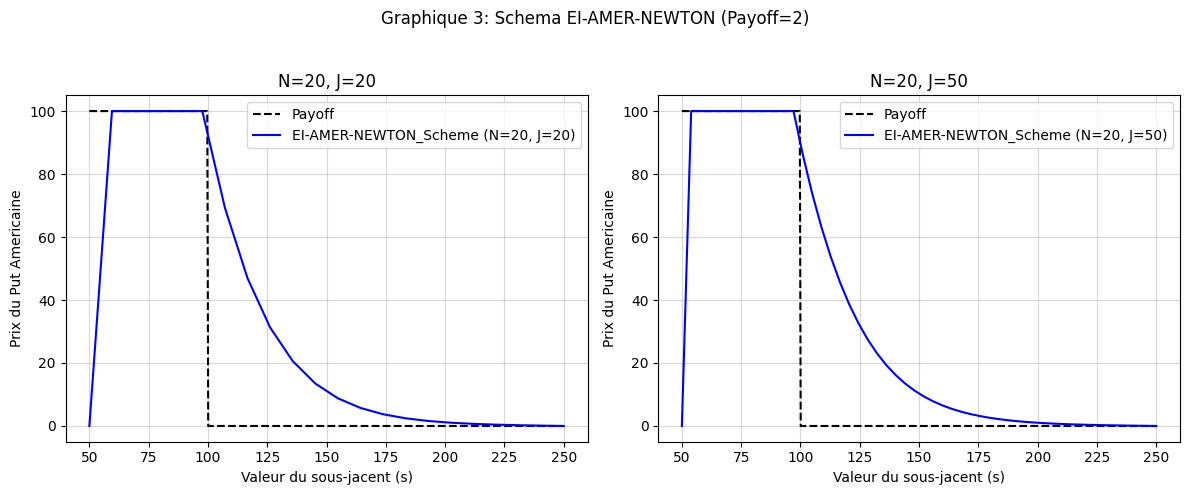

<positron-console-cell-8>:190: RuntimeWarning: divide by zero encountered in scalar divide
<positron-console-cell-8>:195: RuntimeWarning: divide by zero encountered in scalar divide
<positron-console-cell-8>:190: RuntimeWarning: divide by zero encountered in log
<positron-console-cell-8>:195: RuntimeWarning: divide by zero encountered in log


---------------- EI-AMER-NEWTON_scheme ----------------
Numerical Order (Scénario 1: N = J): 
      J    N        U(s)         error     alpha      beta      tcpu
0   10   10   88.773283  8.773283e+00  0.000000  0.000000  0.001670
1   20   20  100.000000  1.122672e+01 -0.381341 -0.355747  0.003306
2   40   40  100.000000  0.000000e+00       inf       inf  0.011474
3   80   80  100.000000  3.552714e-13      -inf      -inf  0.018652
4  160  160  100.000000  1.108447e-12 -1.656342 -1.641546  0.079750
5  320  320  100.000000  1.961098e-12 -0.826833 -0.823122  0.948683
6  640  640  100.000000  1.321609e-12  0.570649  0.569366  9.689670 

----------------------------------------------------------------
Numerical Order (Scénario 2: N = J / 10): 
      J     N        U(s)         error     alpha      beta       tcpu
0   10   100   88.962085  8.962085e+00  0.000000  0.000000   0.018419
1   20   200  100.000000  1.103792e+01 -0.322185 -0.300561   0.035741
2   40   400  100.000000  0.000000e+00  

In [ ]:
schemes_to_test = [
    "EI-AMER-NEWTON",
    "CN-AMER-NEWTON",
    "BDF-AMER-NEWTON"
]

for payoff in payoffs:
    print(f"\n{'#'*80}")
    print(f"{'#'*29} TESTS AVEC PAYOFF {payoff} {'#'*30}")
    print(f"{'#'*80}\n")
    
    for scheme in schemes_to_test:
        print(f"\n{'='*60}")
        print(f"{' '*15}  Schéma: {scheme}")
        print(f"{'='*60}")
        
        config_test = ConfigNumericalTest(
            Smin=Smin, Smax=Smax, Sval=Sval,
            scheme=scheme,
            payoff=payoff, K=K, T=T, sigma=sigma, r=r
        )
        
        test = NumericalTest(config_test)
        test.runTest()